# Avaliação Aprofundada e Interpretabilidade do Modelo

Este notebook complementa a avaliação quantitativa já realizada (F1 macro/weighted, ve
`src/news_classifier/evaluate.py`) com duas análises adicionais:

1. **Matriz de confusão**: visualização de quais categorias o modelo mais confunde entre si, ajudando a entender os padrões de erro de forma mais rica do que o relatório de métricas por classe permite isoladamente.
   
2. **Interpretabilidade do TF-IDF**: como o modelo de produção é linear (Regressão Logística sobre TF-IDF), é possível extrair quais palavras mais contribuem para cada categoria, uma vantagem real sobre modelos de caixa-preta (como Transformers), e um argumento de negócio relevante: o modelo não é apenas preciso, é também explicável.

In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import confusion_matrix

from news_classifier.config import MODELS_DIR
from news_classifier.preprocessing import preparar_dataset
from news_classifier.split import preparar_split

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
FIGURES_PATH = PROJECT_ROOT / 'reports' / 'figures'
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

# Carrega o modelo de produção e os dados de teste (mesmo pipeline validado no projeto)
modelo = joblib.load(MODELS_DIR / "model_v1.joblib")
df = preparar_dataset()
_, df_teste = preparar_split(df)

X_teste, y_teste = df_teste["texto_completo"], df_teste["category"]
y_pred = modelo.predict(X_teste)

print(f"Modelo carregado. Teste: {len(df_teste)} exemplos, {y_teste.nunique()} categorias.")

Modelo carregado. Teste: 22911 exemplos, 22 categorias.


## 1. Matriz de confusão

A matriz de confusão mostra, para cada categoria real (linha), como as predições do modelo se distribuíram entre as categorias previstas (coluna). A diagonal principal representa acertos; valores fora da diagonal mostram exatamente quais pares de categorias o modelo mais confunde entre si, informação mais rica do que precision/recall isolados por classe.


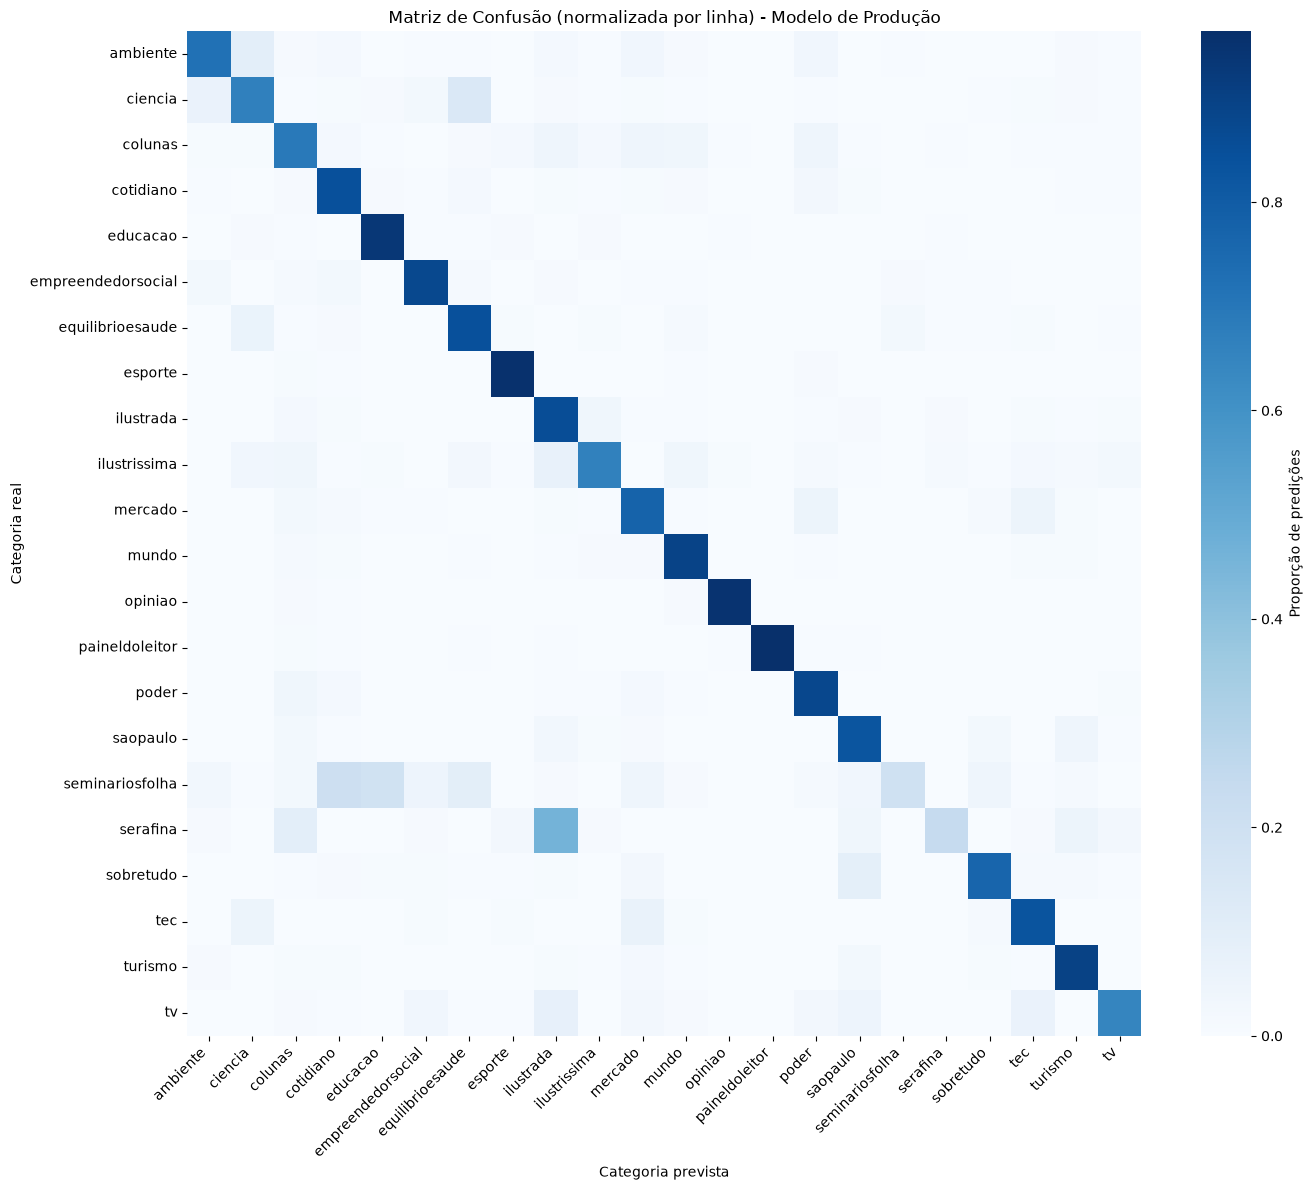

In [2]:
categorias = sorted(y_teste.unique())
matriz = confusion_matrix(y_teste, y_pred, labels=categorias)

# Normaliza por linha (percentual dentro de cada categoria real), facilita comparação
# entre categorias com volumes de teste muito diferentes entre si
matriz_normalizada = matriz.astype(float) / matriz.sum(axis=1, keepdims=True)

plt.figure(figsize=(14, 12))
sns.heatmap(
    matriz_normalizada,
    xticklabels=categorias,
    yticklabels=categorias,
    cmap="Blues",
    annot=False,  # 22x22 fica poluído com números; cor já comunica o padrão
    cbar_kws={"label": "Proporção de predições"},
)
plt.xlabel("Categoria prevista")
plt.ylabel("Categoria real")
plt.title("Matriz de Confusão (normalizada por linha) - Modelo de Produção")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_PATH / "matriz_confusao.png", dpi=120)
plt.show()

**Interpretação:** a diagonal principal domina visualmente o heatmap, confirmando que o
modelo classifica corretamente a grande maioria das notícias em praticamente todas as 22
categorias. As confusões mais visíveis fora da diagonal reforçam os padrões já identificados na análise de erro anterior:

- **`serafina` → `ilustrada`**: a confusão mais evidente do heatmap. Ambas são editorias de comportamento/estilo de vida, com vocabulário fortemente sobreposto, um desafio esperado para um modelo baseado em palavras-chave (TF-IDF), já que a distinção entre elas é mais editorial/estilística do que lexical.
  
- **`seminariosfolha`**: linha visivelmente mais dispersa, sem uma diagonal forte, consistente com a hipótese de que é uma categoria de eventos institucionais, sem vocabulário temático fixo.
  
- **`tec`**: leve dispersão para `mercado`/`colunas`, sugerindo sobreposição de vocabulário técnico-econômico entre essas editorias.

Esses casos representam limites estruturais do problema (categorias editoriais com fronteiras semânticas sobrepostas), não falhas de implementação — e são exatamente o tipo de insight que uma matriz de confusão revela e um F1-score isolado não comunica sozinho.

## 2. Interpretabilidade: quais palavras mais indicam cada categoria

Como o modelo de produção é linear (TF-IDF + Regressão Logística), cada palavra do
vocabulário tem um peso (coeficiente) associado a cada categoria, palavras com peso mais
alto são as que mais "empurram" a predição do modelo na direção daquela categoria. Isso é
uma vantagem real sobre modelos de caixa-preta: conseguimos auditar e explicar exatamente
por que o modelo decide o que decide, o que é valioso tanto para debugging quanto para
comunicar o funcionamento do modelo a stakeholders não técnicos.

In [3]:
# Extrai o vetorizador e o classificador de dentro do pipeline
vetorizador = modelo.named_steps["tfidf"]
classificador = modelo.named_steps["clf"]

vocabulario = np.array(vetorizador.get_feature_names_out())

def top_palavras_por_categoria(categoria, n=10):
    """Retorna as N palavras com maior peso (coeficiente) para uma categoria específica."""
    idx_categoria = list(classificador.classes_).index(categoria)
    coeficientes = classificador.coef_[idx_categoria]
    top_indices = np.argsort(coeficientes)[-n:][::-1]
    return list(zip(vocabulario[top_indices], coeficientes[top_indices]))


# Exibe as top palavras para uma amostra de categorias variadas (temáticas bem distintas)
categorias_exemplo = ["esporte", "mercado", "turismo", "tv", "educacao"]

for cat in categorias_exemplo:
    print(f"\n=== {cat.upper()} ===")
    for palavra, peso in top_palavras_por_categoria(cat, n=10):
        print(f"  {palavra:20s} {peso:.3f}")


=== ESPORTE ===
  clube                6.499
  jogador              5.203
  jogos                5.045
  partida              4.917
  copa                 4.240
  estádio              4.238
  torcedores           4.215
  atacante             3.974
  rio                  3.946
  sportv               3.658

=== MERCADO ===
  banco                3.910
  caminhoneiros        3.734
  petrobras            3.681
  mercado              3.485
  fazenda              3.420
  empresa              3.353
  afirmou              3.287
  disse                3.181
  ibge                 3.130
  petróleo             3.033

=== TURISMO ===
  turismo              9.847
  turistas             8.138
  viagem               6.165
  visitantes           5.534
  hotéis               5.402
  museu                5.202
  hotel                4.682
  viajar               4.637
  turista              4.538
  viagens              4.460

=== TV ===
  leia                 16.635
  tv folha             12.642
  leia 

**Interpretação:** as palavras com maior peso por categoria são semanticamente coerentes e específicas do domínio,"clube", "jogador", "estádio" para `esporte`; "petrobras", "ibge", "petróleo" para `mercado`; "fies", "enem", "professores" para `educacao`. Isso confirma que o modelo aprendeu padrões genuínos de vocabulário editorial, não ruído estatístico espúrio, e oferece uma explicação auditável e comunicável do comportamento do classificador, algo que modelos de caixa-preta (como Transformers sem técnicas adicionais de interpretabilidade, ex. SHAP/LIME) não oferecem de forma tão direta.

Um ponto interessante: a presença de "caminhoneiros" entre as palavras mais fortes de
`mercado` reflete um evento específico do período coberto pelo dataset (greve dos
caminhoneiros de 2018, com forte impacto econômico e ampla cobertura jornalística), um
lembrete de que o modelo captura o contexto histórico dos dados de treino, e pode precisar de retreinamento periódico para se manter relevante à medida que o vocabulário noticioso muda ao longo do tempo.